# Importing Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import random

# -----------------------------------
import tensorflow as tf
import keras
from tensorflow import keras
import keras_tuner as kt

# Downloading the Dataset


In [4]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

## Data Prepocessing

In [5]:
x_train = train_images.reshape(-1,28,28,1)
x_test = test_images.reshape(-1,28,28,1)

In [6]:
train_images  = train_images / 255.0
test_images = test_images / 255.0

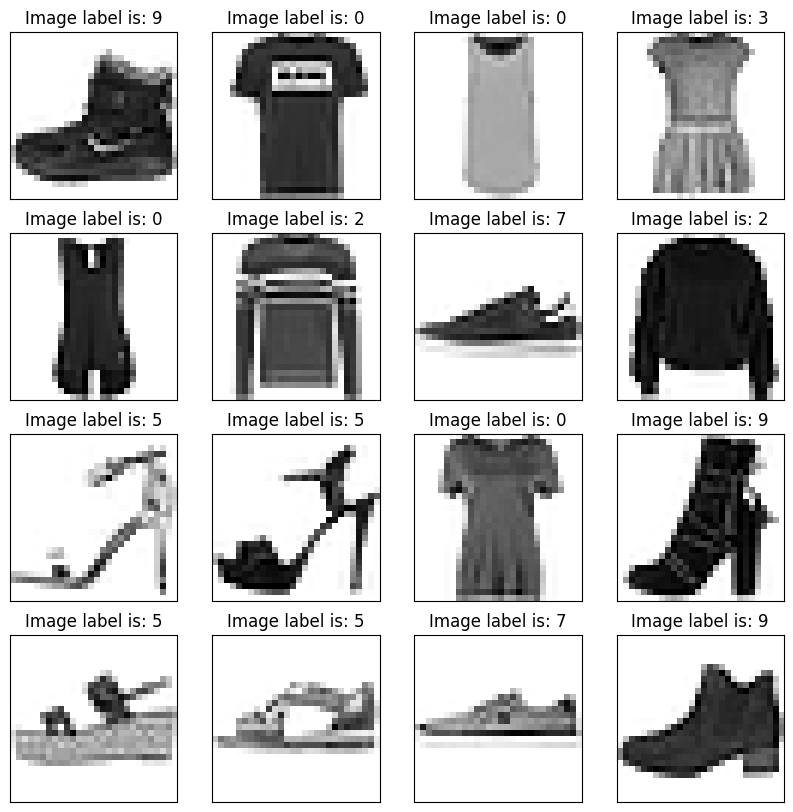

In [7]:
plt.figure(figsize=(10,10))
for i in range(16):# visualizing the first 16 images from the dataset.
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)#showing each image
    #cmap=plt.cm.binary uses a grayscale colormap, making the image appear in black & white.
    plt.title("Image label is: {}".format(train_labels[i]))
plt.show()

# our current visualization shows images in a grid, but we can enhance its clarity with some tweaks



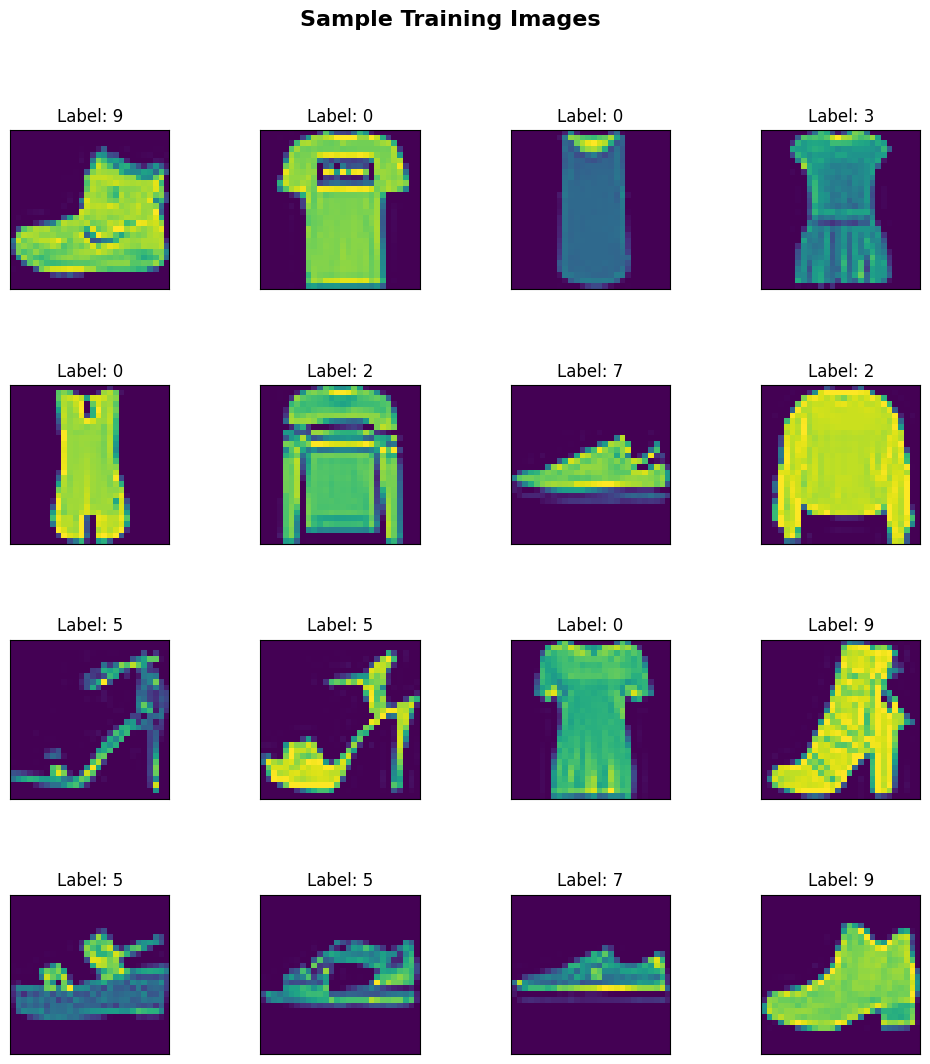

In [8]:
plt.figure(figsize=(12,12))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap='viridis')  # Change colormap for better contrast
    plt.title(f"Label: {train_labels[i]}", fontsize=12)  # Adjust font size

plt.subplots_adjust(wspace=0.4, hspace=0.6)  # Add spacing between images
plt.suptitle("Sample Training Images", fontsize=16, fontweight='bold')  # Main title
plt.show()


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.7349 - loss: 0.7158 - val_accuracy: 0.8470 - val_loss: 0.5733
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8714 - loss: 0.3552 - val_accuracy: 0.8724 - val_loss: 0.4344
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8933 - loss: 0.2896 - val_accuracy: 0.8601 - val_loss: 0.4996
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


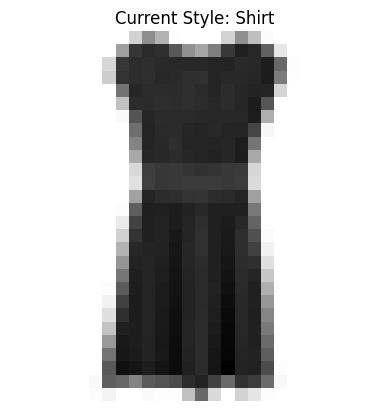

To match the sporty style, consider adding: Ankle Boot.


In [9]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize images
train_images, test_images = train_images / 1000.0, test_images / 400.0

# Reshape for CNN compatibility
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

# Define fashion categories
fashion_labels = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

# Define fashion genres (user preferences)
fashion_genres = {
    "casual": ["T-shirt/Top", "Sneaker", "Trouser"],
    "formal": ["Shirt", "Dress", "Coat"],
    "streetwear": ["Pullover", "Sneaker", "Bag"],
    "sporty": ["T-shirt/Top", "Shoes", "Ankle Boot"]
}

# Build the CNN Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # 10 classes in Fashion MNIST
])

# Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the Model with 3 epochs
model.fit(train_images, train_labels, epochs=3, validation_data=(test_images, test_labels))

# Function to Predict Fashion & Suggest Improvements
def predict_fashion(image_path, user_preferred_style):
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to match model input size
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_array)
    predicted_label = fashion_labels[np.argmax(prediction)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Current Style: {predicted_label}")
    plt.axis('off')
    plt.show()

    # Check if the predicted style aligns with the user's desired genre
    if predicted_label in fashion_genres[user_preferred_style]:
        suggestion = "You're already matching your preferred fashion style! Keep it up!"
    else:
        # Suggest an item from the preferred style category
        suggested_item = random.choice(fashion_genres[user_preferred_style])
        suggestion = f"To match the {user_preferred_style} style, consider adding: {suggested_item}."

    return suggestion

# Example Usage
image_path = "C:/Users/prakr/OneDrive/Pictures/e580bf5dab266348c894501c536eab35.jpeg"
user_preferred_style = "sporty"  # User selects preferred fashion genre

style_advice = predict_fashion(image_path, user_preferred_style)
print(style_advice)


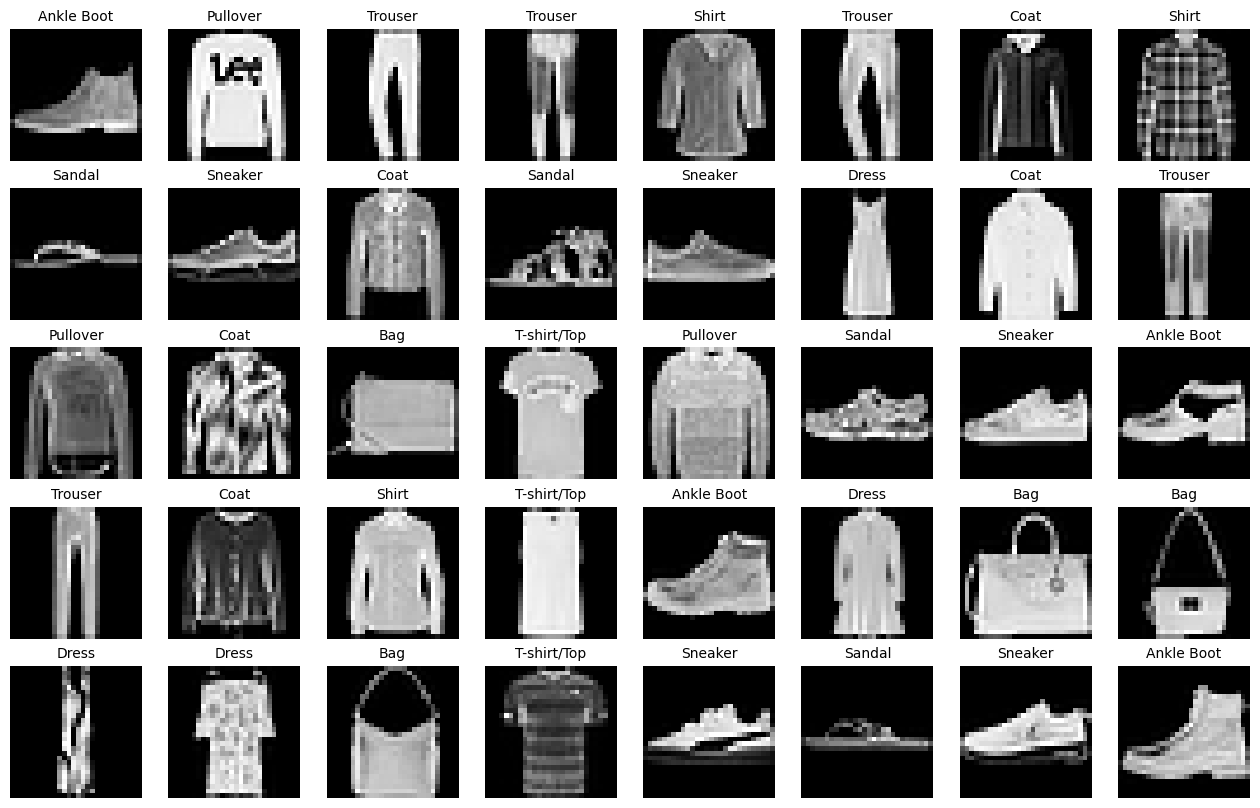

In [9]:
import matplotlib.pyplot as plt

# Define fashion labels
fashion_labels = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

# Function to plot more test images
def plot_sample_images(test_images, test_labels, cmap="gray"):
    f, ax = plt.subplots(5, 8, figsize=(16, 10))  # 5 rows, 8 columns = 40 images
    for i, img in enumerate(test_images[:40]):  # Show first 40 test images
        ax[i // 8, i % 8].imshow(img, cmap=cmap)
        ax[i // 8, i % 8].axis("off")
        ax[i // 8, i % 8].set_title(fashion_labels[test_labels[i]], fontsize=10)
    plt.show()

# Call function to display test images
plot_sample_images(test_images, test_labels)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.7716 - loss: 0.6371 - val_accuracy: 0.8650 - val_loss: 0.3738
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8843 - loss: 0.3170 - val_accuracy: 0.8935 - val_loss: 0.2952
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9031 - loss: 0.2677 - val_accuracy: 0.9000 - val_loss: 0.3027
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9113 - loss: 0.2376 - val_accuracy: 0.9115 - val_loss: 0.2597
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9228 - loss: 0.2089 - val_accuracy: 0.9015 - val_loss: 0.2720
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


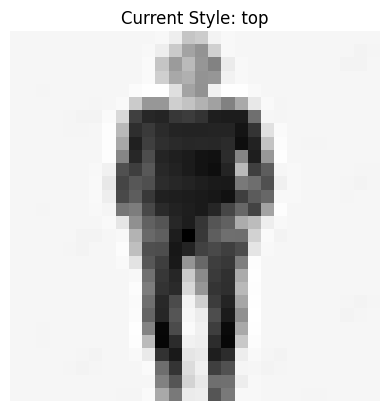

To match the formal style, consider adding: Dress.


In [10]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Modify dataset size (use more training images)
train_size = int(len(train_images) * 0.80)  # 80% for training
test_size = int(len(test_images) * 0.20)  # 20% for testing

train_images, train_labels = train_images[:train_size], train_labels[:train_size]
test_images, test_labels = test_images[:test_size], test_labels[:test_size]

# Normalize images
train_images, test_images = train_images / 255.0, test_images / 255.0

# Reshape for CNN compatibility
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

# Define fashion categories 
fashion_labels = ["saree", "top", "Dress", "gown",
                  "Sandal", "Shirt", "suit", "kurti", "sandel"]

# Define fashion genres (user preferences)
fashion_genres = {
    "casual": ["Top", "Sneaker", "Trouser"],
    "formal": ["Shirt", "Dress", "tshirt"],
    "streetwear": ["Pullover", "Sneaker", "Bag"],
    "sporty": ["hoodie", "gym-shorts", "shoes"]
}

# Build the CNN Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # 10 classes in Fashion MNIST
])

# Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the Model with 5 epochs (adjusted)
model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

# Function to Predict Fashion & Suggest Improvements
def predict_fashion(image_path, user_preferred_style):
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to match model input size
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_array)
    predicted_label = fashion_labels[np.argmax(prediction)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Current Style: {predicted_label}")
    plt.axis('off')
    plt.show()

    # Check if the predicted style aligns with the user's desired genre
    if predicted_label in fashion_genres[user_preferred_style]:
        suggestion = "You're already matching your preferred fashion style! Keep it up!"
    else:
        # Suggest an item from the preferred style category
        suggested_item = random.choice(fashion_genres[user_preferred_style])
        suggestion = f"To match the {user_preferred_style} style, consider adding: {suggested_item}."

    return suggestion

# Example Usage
image_path ="C:/Users/prakr/OneDrive/Pictures/pngtree-middle-agedwoman-in-trendy-clothing-single-png-image_10696991.png"
user_preferred_style = "formal"  # User selects preferred fashion genre

style_advice = predict_fashion(image_path, user_preferred_style)
print(style_advice)



In [12]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)
     

In [13]:
train_images.shape
     

(48000, 28, 28, 1)

In [14]:
test_images.shape

(2000, 28, 28, 1)

In [15]:
import tensorflow as tf
from tensorflow.keras import models, layers

# Build the convolutional base
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # Softmax for classification
])

# Compile and train the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

     

In [22]:
# Training model accuracy
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))
     

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.7477 - loss: 0.6962 - val_accuracy: 0.8719 - val_loss: 0.3628
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8770 - loss: 0.3367 - val_accuracy: 0.8862 - val_loss: 0.3191
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8968 - loss: 0.2830 - val_accuracy: 0.8930 - val_loss: 0.2935
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9079 - loss: 0.2470 - val_accuracy: 0.8946 - val_loss: 0.2894
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9183 - loss: 0.2190 - val_accuracy: 0.8955 - val_loss: 0.2855


In [23]:
#testing model accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 2s - 7ms/step - accuracy: 0.8955 - loss: 0.2855

Test accuracy: 0.8955000042915344


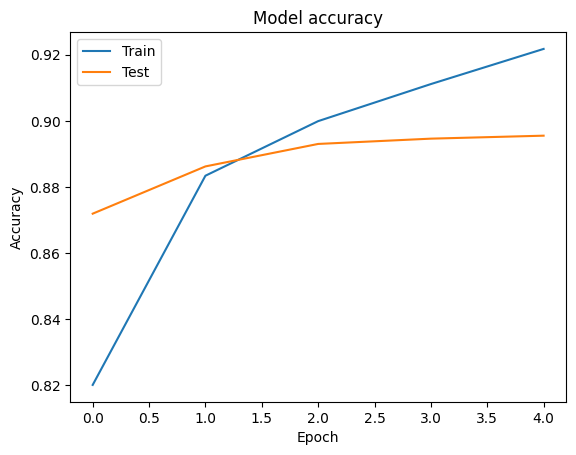

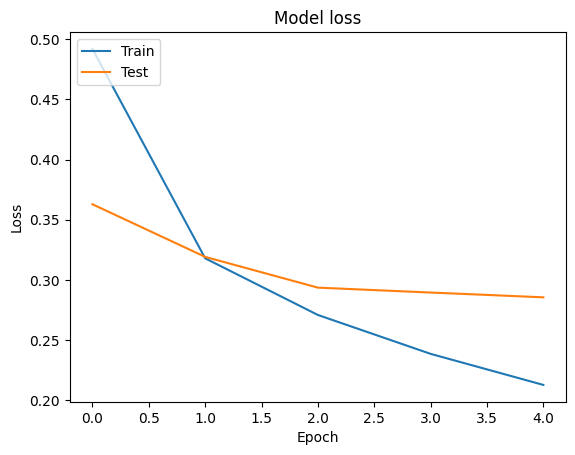

In [24]:

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


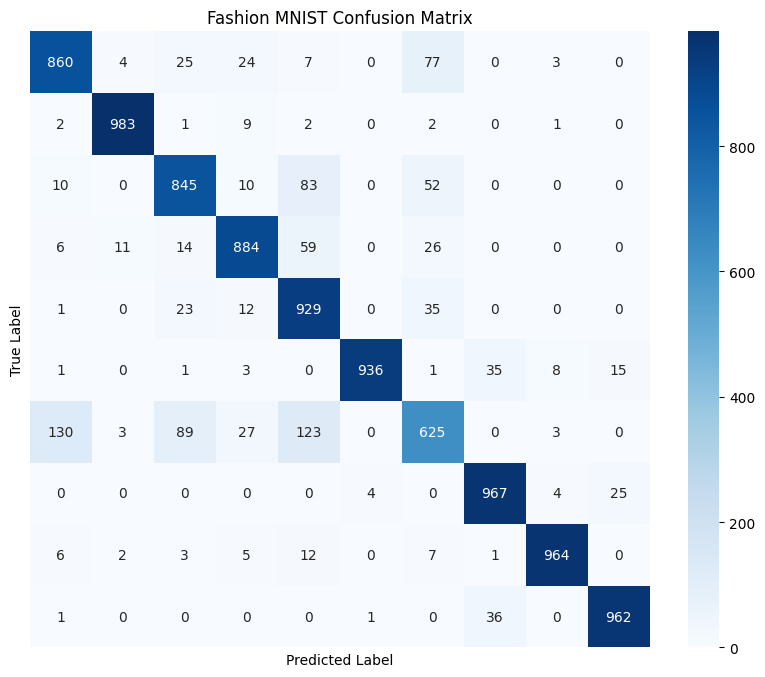

In [27]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on the test set
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(test_labels, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=[], yticklabels=[])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion MNIST Confusion Matrix")
plt.show()


In [36]:
# After training is complete
model.save("my_model.h5")  # Save in HDF5 format
print("Model saved to my_model.h5")


Model saved to my_model.h5


In [37]:
model = load_model("my_model.h5")  # Make sure this file is in the same folder


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7613 - loss: 0.6594 - val_accuracy: 0.8775 - val_loss: 0.3506
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8795 - loss: 0.3302 - val_accuracy: 0.8860 - val_loss: 0.3222
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8992 - loss: 0.2728 - val_accuracy: 0.8980 - val_loss: 0.2971
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9120 - loss: 0.2347 - val_accuracy: 0.9090 - val_loss: 0.2661
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9227 - loss: 0.2051 - val_accuracy: 0.9035 - val_loss: 0.2911
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


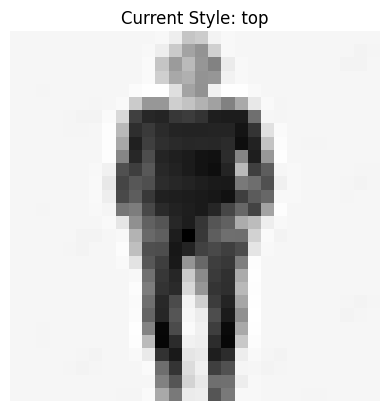

To match the formal style, consider adding: Shirt with pants.


In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Modify dataset size (use more training images)
train_size = int(len(train_images) * 0.80)  # 80% for training
test_size = int(len(test_images) * 0.20)  # 20% for testing

train_images, train_labels = train_images[:train_size], train_labels[:train_size]
test_images, test_labels = test_images[:test_size], test_labels[:test_size]

# Normalize images
train_images, test_images = train_images / 255.0, test_images / 255.0

# Reshape for CNN compatibility
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

# Define fashion categories 
fashion_labels = ["saree", "top", "Dress", "gown",
                  "Sandal", "Shirt", "suit", "kurti", "sandel"]

# Define fashion genres (user preferences)
fashion_genres = {
    "casual": ["Top", "Sneaker", "Trouser"],
    "formal": ["Shirt with pants", "Dress with heels", "tshirt with blazer"],
    "streetwear": ["Pullover", "Sneaker", "Bag"],
    "sporty": ["hoodie", "gym-shorts", "shoes"]
}

# Build the CNN Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # 10 classes in Fashion MNIST
])

# Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the Model with 5 epochs (adjusted)
model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

# Function to Predict Fashion & Suggest Improvements
def predict_fashion(image_path, user_preferred_style):
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to match model input size
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_array)
    predicted_label = fashion_labels[np.argmax(prediction)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Current Style: {predicted_label}")
    plt.axis('off')
    plt.show()

    # Check if the predicted style aligns with the user's desired genre
    if predicted_label in fashion_genres[user_preferred_style]:
        suggestion = "You're already matching your preferred fashion style! Keep it up!"
    else:
        # Suggest an item from the preferred style category
        suggested_item = random.choice(fashion_genres[user_preferred_style])
        suggestion = f"To match the {user_preferred_style} style, consider adding: {suggested_item}."

    return suggestion

# Example Usage
image_path ="C:/Users/prakr/OneDrive/Pictures/pngtree-middle-agedwoman-in-trendy-clothing-single-png-image_10696991.png"
user_preferred_style = "formal"  # User selects preferred fashion genre

style_advice = predict_fashion(image_path, user_preferred_style)
print(style_advice)